# Part D: The trade-off
Downstream head pose estimation requires landmarks accurate to within 5% NME. Frames where that cannot be met should be withheld rather than passed on with a silent error, since a confidently wrong landmark set produces a confidently wrong pose. Withholding too often leaves the pose and eye-state features unavailable and the product unusable.

Two requirements apply:

At least **95%** of accepted frames must fall within 5% NME.

Coverage must be at least **85%** overall, and at least **70%** on the occlusion subset.

These are in tension. Design a decision strategy that satisfies both, or demonstrate why they cannot be satisfied together and state what would have to change.

You have both estimators from Parts A and B available, and their errors may not be correlated. Their disagreement is a signal you can compute at inference time without labels. Whether you use that, a confidence signal from the model itself, or something else is your decision. Implement what you can; for anything left unfinished, describe the design clearly enough that an engineer could implement it.

Show the trade-off explicitly: where does your system sit on the curve, and what happens if you push in either direction?

Finally, what would you monitor in production to detect this balance drifting over time? Assume you have no ground-truth landmarks from the vehicle.

## 1. 준비: 신호 계산

신호는 라벨 없이 추론 시점에 계산 가능한 **A–B disagreement**(정규화된 두 예측
간 평균 거리). 근거와 한계는 `src/application/accept_reject_use_case.py` docstring,
`DESIGN.md` §5/E-3 참조.

In [1]:
import sys, os
sys.path.append(os.path.abspath("../.."))

In [5]:
%matplotlib inline
from src.shared.nme_metrics import nme_batch
from src.application.accept_reject_use_case import disagreement_signal, sweep, report
from src.settings import EvalConfig

import numpy as np
import matplotlib.pyplot as plt

In [8]:
REPO_ROOT = os.path.abspath("../..")

eval_config = EvalConfig()
nme_threshold = 0.05
precision_req = 0.95
coverage_all_req = 0.85
coverage_occ_req = 0.70

In [ ]:
preds_result = np.load(f"{REPO_ROOT}/output/results/preds.npz", allow_pickle="True")
preds_a, preds_b, gts, boxes, attrs, img_wh, paths = (
                                                        preds_result["predsA"], 
                                                        preds_result["predsB"], 
                                                        preds_result["gts"], 
                                                        preds_result["boxes"], 
                                                        preds_result["attrs"], 
                                                        preds_result["img_wh"], 
                                                        preds_result["paths"],
                                                    )
occ = attrs[:, 4].astype(bool)

2500

In [7]:
nme, _ = nme_batch(preds_b, gts, eval_config.norm, boxes)
signal = disagreement_signal(preds_a, preds_b)
print("signal n =", len(signal), " range =", (signal.min(), signal.max()))

signal n = 2500  range = (0.03389307297253654, 0.9667874259374668)


## 2. accept/reject 스윕 + feasible 지점 탐색

요구조건: precision≥95%(수용분 중 5%NME 이내), coverage≥85%(전체),
coverage_occ≥70%(occlusion). 임계값 τ를 낮은→높은 쪽으로 쓸며 두 지표를 계산.

In [ ]:
curve, feasible = sweep(signal, nme, occ, nme_thr=nme_threshold,
                        prec_req=precision_req,
                        cov_all_req=coverage_all_req,
                        cov_occ_req=coverage_occ_req)
report(feasible)

# 핵심 참고 지점들: no-reject, coverage요건 만족하는 최고정밀도, 곡선상 최고정밀도
i_full = int(np.argmax(curve["coverage"]))
print("\n[no-reject]           ", {k: round(float(curve[k][i_full]), 4) for k in curve})

mask = (curve["coverage"] >= coverage_all_req) & (curve["coverage_occ"] >= coverage_occ_req)
if mask.any():
    i = np.where(mask)[0][np.argmax(curve["precision"][mask])]
    print("[coverage요건 만족 중 최고precision]", {k: round(float(curve[k][i]), 4) for k in curve})
else:
    print("[coverage요건 만족 중 최고precision] 없음")

i_best = int(np.argmax(curve["precision"]))
print("[곡선상 최고precision]  ", {k: round(float(curve[k][i_best]), 4) for k in curve})

## 3. 트레이드오프 곡선

τ↑ → coverage↑ precision↓ (silent error 위험↑) / τ↓ → precision↑ coverage↓
(feature 미제공↑, 제품성↓). feasible 지점이 있으면 곡선 위에 점으로 표시.

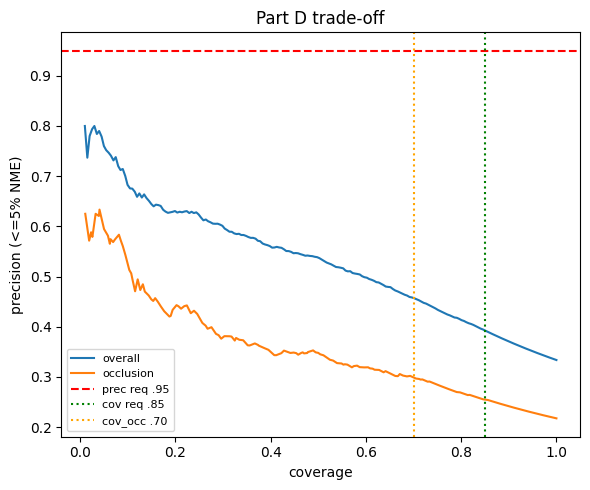

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(curve["coverage"], curve["precision"], "-", label="overall")
ax.plot(curve["coverage_occ"], curve["precision_occ"], "-", label="occlusion")
ax.axhline(precision_req, ls="--", c="r", label="prec req .95")
ax.axvline(coverage_all_req, ls=":", c="g", label="cov req .85")
ax.axvline(coverage_occ_req, ls=":", c="orange", label="cov_occ .70")
if feasible:
    ax.scatter([feasible["coverage"]], [feasible["precision"]], s=120, c="k",
               zorder=5, label="operating point")
ax.set_xlabel("coverage"); ax.set_ylabel("precision (<=5% NME)")
ax.set_title("Part D trade-off"); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. (E-3) disagreement는 오차의 proxy일 뿐: 두 실패 방향 정량화

방향①(위험): 신호는 낮은데 실제 오차는 큼 → false-accept, Part D가 못 막는 위험.
방향②: 신호는 큰데 실제로는 정확 → false-reject, 불필요한 커버리지 손실.

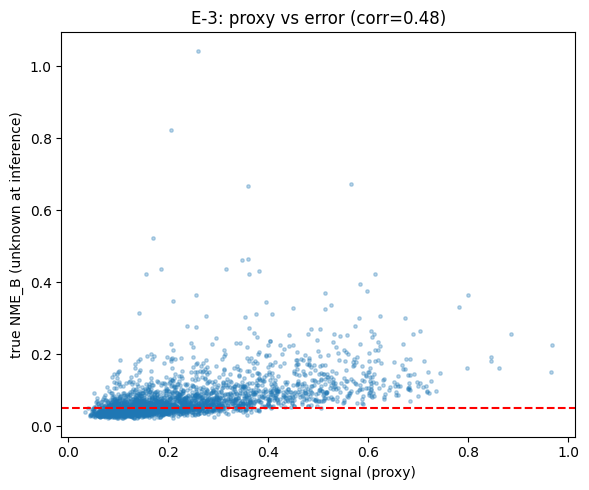

corr(signal, NME_B) = 0.484
방향① false-accept 질량: 전체의 0.231 (신호 하위50% 안에서는 0.462)
방향② false-reject 후보 질량: 전체의 0.064


In [11]:
r = np.corrcoef(signal, nme)[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(signal, nme, s=6, alpha=0.3)
ax.axhline(nme_threshold, ls="--", c="r")
if feasible:
    ax.axvline(feasible["thr"], ls="--", c="k")
ax.set_xlabel("disagreement signal (proxy)")
ax.set_ylabel("true NME_B (unknown at inference)")
ax.set_title(f"E-3: proxy vs error (corr={r:.2f})")
fig.tight_layout()
plt.show()

low_sig, high_err = signal <= np.median(signal), nme > nme_threshold
fa_all = (low_sig & high_err).mean()
fa_cond = high_err[low_sig].mean()
fr_all = (~low_sig & ~high_err).mean()
print(f"corr(signal, NME_B) = {r:.3f}")
print(f"방향① false-accept 질량: 전체의 {fa_all:.3f} (신호 하위50% 안에서는 {fa_cond:.3f})")
print(f"방향② false-reject 후보 질량: 전체의 {fr_all:.3f}")

## 5. 결론

**요구조건 동시 만족 불가.**
- coverage를 1%까지 줄여도 precision이 80% 근처에서 정체되어 95% 미달(§2 "곡선상 최고precision")
- 애초 가설("occlusion 꼬리 → coverage_occ 붕괴")보다 근본적: **disagreement 신호 자체가 B의 오차를 95% 신뢰도로 걸러내지 못함**(§4 corr=0.484)
- no-reject 기준선도 낮음(overall 33%, occlusion 22%만 5%NME 이내). 신호 품질보다 B의 절대 정확도 부족이 더 큼

**바뀌어야 할 것:** (1) B 정확도 개선(in-cabin/occlusion 데이터, 예산 헤드룸), (2) 신호 개선(보조 히트맵 confidence, `DESIGN.md` §8), (3) 그럼에도 불충분하면 downstream 5%NME 기준 완화.

### 프로덕션 모니터링 (차량에 GT 없음 가정)
- disagreement 신호 분포 + **acceptance rate** 추적, 급변 시 알람
- 입력 품질 proxy: 얼굴 박스 크기, blur(라플라시안 분산), 밝기/대비
- 참조 분포 대비 **PSI/KL 드리프트**(웹→IR 도메인 이동)
- downstream pose의 프레임 간 jitter로 간접 오차 감시
- 표류 정의: acceptance rate/disagreement 분포가 참조 대비 유의하게 이동 → "5%NME 만족" 가정 붕괴 신호